
# FULL RUN — ROBUST DOWNLOAD + ECG CHANNEL FIX
## An Uncertainty-Aware Explainable and Drift-Adaptive Edge-IoMT Framework for Real-Time Cardiovascular Event Detection from Wearable ECG and PPG Signals

### Important fix in this version
The earlier notebook used `pip -U`, which can upgrade NumPy inside the live Colab runtime and create a binary/version mismatch with SciPy. This version **does not upgrade NumPy, SciPy, pandas, matplotlib, or scikit-learn**.

It installs only the extra packages required by this project with `--no-deps`, preserving Colab's tested scientific Python stack.

### Primary dataset
PhysioNet **BIDMC PPG and Respiration Dataset v1.0.0**.

### Endpoint
The BIDMC dataset does not contain cardiologist-adjudicated arrhythmia labels. Therefore the notebook uses monitor-derived heart-rate alert states:
- HR < 50 bpm: Bradycardia alert
- 50–100 bpm: Normal-rate state
- HR > 100 bpm: Tachycardia alert

If a split contains fewer than all three classes, the notebook automatically works with the classes that are actually present, preventing model/class-index errors.


### Additional corrections in this revision
1. HTTP 429/500/502/503/504 responses are automatically retried with exponential backoff.
2. Partial `.dat`/`.hea` downloads are rejected instead of being silently used.
3. Already validated files are reused, so rerunning the download cell resumes rather than starts over.
4. BIDMC ECG is selected correctly from physiological lead names such as **II**, **V**, or **AVR**. The previous resolver incorrectly expected the channel name to contain `ECG`/`EKG`.


In [1]:

#@title 1. SAFE package setup — DO NOT UPGRADE NumPy/SciPy
import sys, subprocess, importlib.util, os

# Preserve the pre-tested Colab NumPy/SciPy stack.
# Install only packages that are not already available, and do not let pip alter dependencies.
packages = {
    "wfdb": "wfdb",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "shap": "shap",
    "river": "river",
    "joblib": "joblib",
}
missing = [pip_name for mod, pip_name in packages.items() if importlib.util.find_spec(mod) is None]

if missing:
    print("Installing missing project packages without changing NumPy/SciPy:", missing)
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", *missing
    ])
else:
    print("All project packages are already available.")

print("SAFE setup complete.")


Installing missing project packages without changing NumPy/SciPy: ['wfdb', 'river']
SAFE setup complete.


In [2]:

#@title 2. Scientific stack compatibility check and imports
import warnings, os, re, json, time, random, zipfile, urllib.request, platform
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import signal, stats
from scipy.optimize import minimize_scalar

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, log_loss, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

import joblib
import wfdb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

FS = 125
WINDOW_SEC = 20
STEP_SEC = 10
BOOTSTRAPS = 1500

OUT = Path("/content/edge_iomt_results")
OUT.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("pandas:", pd.__version__)
print("Scientific stack imported successfully.")


Python: 3.13.15
NumPy: 2.1.3
SciPy: 1.16.3
pandas: 2.2.3
Scientific stack imported successfully.


In [3]:

#@title 3. ROBUST BIDMC download with automatic retry and file validation
import requests, time, os
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

BASE = "https://physionet.org/files/bidmc/1.0.0"
DATA = Path("/content/bidmc")
DATA.mkdir(parents=True, exist_ok=True)

records = [f"bidmc{i:02d}" for i in range(1, 54)]

retry = Retry(
    total=12,
    connect=12,
    read=12,
    backoff_factor=1.5,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=frozenset(["GET"])
)
session = requests.Session()
session.mount("https://", HTTPAdapter(max_retries=retry))

def valid_local_file(path, min_bytes):
    return path.exists() and path.stat().st_size >= min_bytes

def robust_download(url, dst, min_bytes, attempts=4):
    dst = Path(dst)
    tmp = Path(str(dst) + ".part")

    if valid_local_file(dst, min_bytes):
        return True

    for attempt in range(1, attempts + 1):
        try:
            if tmp.exists():
                tmp.unlink()

            with session.get(url, stream=True, timeout=(20, 120)) as response:
                response.raise_for_status()
                with open(tmp, "wb") as f:
                    for chunk in response.iter_content(chunk_size=1024 * 256):
                        if chunk:
                            f.write(chunk)

            if tmp.stat().st_size < min_bytes:
                raise IOError(
                    f"Incomplete file: {tmp.name}, only {tmp.stat().st_size} bytes"
                )

            os.replace(tmp, dst)
            return True

        except Exception as e:
            print(f"Retry {attempt}/{attempts} for {dst.name}: {e}")
            if tmp.exists():
                tmp.unlink()
            time.sleep(min(20, 2 ** attempt))

    return False

# Expected minimum sizes are deliberately conservative:
# waveform .dat > 100 KB, waveform .hea > 150 B,
# numeric .dat > 1 KB, numeric .hea > 150 B.
download_log = []

for i, r in enumerate(records, 1):
    specs = [
        (f"{r}.hea",   150),
        (f"{r}.dat",   100_000),
        (f"{r}n.hea",  150),
        (f"{r}n.dat",  1_000),
    ]

    status = True
    for fname, min_bytes in specs:
        ok = robust_download(
            f"{BASE}/{fname}",
            DATA / fname,
            min_bytes=min_bytes
        )
        status = status and ok

    download_log.append({"record": r, "complete": status})
    if i % 5 == 0 or i == len(records):
        print(f"Validated {i}/{len(records)} records")

download_log = pd.DataFrame(download_log)
display(download_log["complete"].value_counts())
download_log.to_csv(OUT / "download_validation.csv", index=False)

complete_records = download_log.loc[download_log["complete"], "record"].tolist()
print("Fully downloaded records:", len(complete_records), "/", len(records))

# Do NOT stop because of one transient server failure.
# We require enough complete subjects for subject-wise analysis.
assert len(complete_records) >= 20, (
    f"Only {len(complete_records)} complete records were downloaded. "
    "PhysioNet is still returning repeated server/network errors. "
    "Wait a few minutes and rerun ONLY this cell; completed files will not be downloaded again."
)


Validated 5/53 records
Validated 10/53 records
Validated 15/53 records
Validated 20/53 records
Validated 25/53 records
Validated 30/53 records
Validated 35/53 records
Validated 40/53 records
Validated 45/53 records
Validated 50/53 records
Validated 53/53 records


,count
complete,
True,53


Fully downloaded records: 53 / 53


In [4]:

#@title 4. Dataset audit with correct ECG/PPG/HR channel recognition
def normalize_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def choose_ecg_channel(names):
    # BIDMC ECG channels are commonly named by leads (II, V, AVR),
    # not literally "ECG". Prefer Lead II because PhysioNet's MATLAB
    # representation identifies Lead II as the ECG signal.
    normalized = [normalize_name(x) for x in names]

    exact_priority = ["ii", "ecg", "ekg", "v", "avr"]
    for target in exact_priority:
        if target in normalized:
            return normalized.index(target)

    # Fallback for uncommon lead labels.
    for i, n in enumerate(normalized):
        if any(k in n for k in ["ecg", "ekg"]):
            return i
    return None

def choose_ppg_channel(names):
    normalized = [normalize_name(x) for x in names]
    for target in ["pleth", "ppg"]:
        if target in normalized:
            return normalized.index(target)
    for i, n in enumerate(normalized):
        if "pleth" in n or "ppg" in n:
            return i
    return None

def choose_hr_channel(names):
    normalized = [normalize_name(x) for x in names]
    for target in ["hr", "heartrate"]:
        if target in normalized:
            return normalized.index(target)
    return None

audit = []
valid_records = []

for r in complete_records:
    try:
        rec = wfdb.rdrecord(str(DATA / r))
        num = wfdb.rdrecord(str(DATA / (r + "n")))

        ecg_i = choose_ecg_channel(rec.sig_name)
        ppg_i = choose_ppg_channel(rec.sig_name)
        hr_i = choose_hr_channel(num.sig_name)

        ok = ecg_i is not None and ppg_i is not None and hr_i is not None

        audit.append({
            "record": r,
            "waveform_fs": rec.fs,
            "waveform_samples": rec.sig_len,
            "waveform_channels": " | ".join(rec.sig_name),
            "numeric_channels": " | ".join(num.sig_name),
            "selected_ECG": rec.sig_name[ecg_i] if ecg_i is not None else "",
            "selected_PPG": rec.sig_name[ppg_i] if ppg_i is not None else "",
            "selected_HR": num.sig_name[hr_i] if hr_i is not None else "",
            "status": "OK" if ok else "MISSING_REQUIRED_CHANNEL"
        })

        if ok:
            valid_records.append(r)

    except Exception as e:
        audit.append({"record": r, "status": f"READ_ERROR: {e}"})

audit_df = pd.DataFrame(audit)
display(audit_df)
audit_df.to_csv(OUT / "dataset_audit.csv", index=False)

print("Records usable for ECG+PPG+HR analysis:", len(valid_records))
assert len(valid_records) >= 20, (
    f"Only {len(valid_records)} usable records remain. "
    "Rerun the robust download cell if any records show READ_ERROR."
)


,record,waveform_fs,waveform_samples,waveform_channels,numeric_channels,selected_ECG,selected_PPG,selected_HR,status
0,bidmc01,125,60001,"RESP, | PLETH, | V, | AVR, | II,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
1,bidmc02,125,60001,"II, | PLETH, | RESP, | V, | AVR,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
2,bidmc03,125,60001,"RESP, | PLETH, | II, | V, | AVR, | CVP,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
3,bidmc04,125,60001,"RESP, | PLETH, | II, | V, | AVR, | ABP,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
4,bidmc05,125,60001,"RESP, | PLETH, | II, | V, | AVR,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
5,bidmc06,125,60001,"RESP, | ABP, | CVP, | PLETH, | II, | V, | AVR,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
6,bidmc07,125,60001,"RESP, | PLETH, | II, | V, | AVR, | CVP, | ART,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
7,bidmc08,125,60001,"RESP, | PLETH, | II, | V, | AVR, | ART, | CVP,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
8,bidmc09,125,60001,"RESP, | PLETH, | I, | V, | II, | ABP,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK
9,bidmc10,125,60001,"RESP, | PLETH, | II, | V, | AVR, | CVP,","HR, | PULSE, | RESP, | SpO2,","II,","PLETH,","HR,",OK


Records usable for ECG+PPG+HR analysis: 53


In [5]:

#@title 5. Signal-processing and feature-extraction functions
def channel_index(names, keys):
    names_l = [str(x).lower() for x in names]
    for key in keys:
        for i, name in enumerate(names_l):
            if key in name:
                return i
    return None

def interpolate_signal(x):
    x = np.asarray(x, dtype=float)
    return pd.Series(x).interpolate(limit_direction="both").bfill().ffill().to_numpy()

def bandpass(x, lo, hi, fs=FS, order=3):
    x = interpolate_signal(x)
    if len(x) < 50:
        return x
    ny = fs / 2.0
    hi = min(hi, ny * 0.98)
    b, a = signal.butter(order, [lo/ny, hi/ny], btype="band")
    try:
        return signal.filtfilt(b, a, x)
    except Exception:
        return x

def safe_skew(x):
    try:
        v = stats.skew(x)
        return float(v) if np.isfinite(v) else 0.0
    except Exception:
        return 0.0

def safe_kurt(x):
    try:
        v = stats.kurtosis(x)
        return float(v) if np.isfinite(v) else 0.0
    except Exception:
        return 0.0

def extract_features(x, prefix, fs=FS):
    x = interpolate_signal(x)
    out = {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_median": float(np.median(x)),
        f"{prefix}_iqr": float(stats.iqr(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_max": float(np.max(x)),
        f"{prefix}_rms": float(np.sqrt(np.mean(x*x))),
        f"{prefix}_skew": safe_skew(x),
        f"{prefix}_kurt": safe_kurt(x),
    }

    f, pxx = signal.welch(x, fs=fs, nperseg=min(512, len(x)))
    den = float(np.sum(pxx) + 1e-12)
    out[f"{prefix}_domfreq"] = float(f[np.argmax(pxx)])
    out[f"{prefix}_spec_centroid"] = float(np.sum(f * pxx) / den)
    out[f"{prefix}_power_0p5_3"] = float(np.sum(pxx[(f >= 0.5) & (f < 3)]) / den)
    out[f"{prefix}_power_3_8"] = float(np.sum(pxx[(f >= 3) & (f < 8)]) / den)

    distance = max(1, int(fs * 60 / 220))
    prominence = max(float(np.std(x) * 0.35), 1e-8)
    peaks, _ = signal.find_peaks(x, distance=distance, prominence=prominence)

    rr = np.diff(peaks) / fs if len(peaks) >= 2 else np.array([])
    rr = rr[(rr > 60/220) & (rr < 60/35)]
    out[f"{prefix}_peak_count"] = int(len(peaks))
    out[f"{prefix}_rate"] = float(60 / np.mean(rr)) if len(rr) else np.nan
    out[f"{prefix}_ibi_std"] = float(np.std(rr)) if len(rr) else np.nan
    out[f"{prefix}_rmssd"] = (
        float(np.sqrt(np.mean(np.diff(rr)**2))) if len(rr) > 1 else np.nan
    )
    return out

def ecg_ppg_lag(ecg, ppg, fs=FS):
    ecg = interpolate_signal(ecg)
    ppg = interpolate_signal(ppg)
    e = (ecg - np.mean(ecg)) / (np.std(ecg) + 1e-8)
    p = (ppg - np.mean(ppg)) / (np.std(ppg) + 1e-8)
    cc = signal.correlate(p, e, mode="full", method="fft")
    lags = signal.correlation_lags(len(p), len(e), mode="full")
    mask = (lags >= 0) & (lags <= int(0.6 * fs))
    if not np.any(mask):
        return np.nan
    return float(lags[mask][np.argmax(cc[mask])] / fs)


In [6]:

#@title 6. Build synchronized ECG+PPG window dataset
rows = []

for ridx, r in enumerate(valid_records, 1):
    rec = wfdb.rdrecord(str(DATA / r))
    num = wfdb.rdrecord(str(DATA / (r + "n")))

    ecg_i = choose_ecg_channel(rec.sig_name)
    ppg_i = choose_ppg_channel(rec.sig_name)
    hr_i  = choose_hr_channel(num.sig_name)

    if ecg_i is None or ppg_i is None or hr_i is None:
        print("Skipping", r, "- required ECG/PPG/HR channel unavailable")
        continue

    ecg = rec.p_signal[:, ecg_i]
    ppg = rec.p_signal[:, ppg_i]
    hr  = num.p_signal[:, hr_i]

    win = int(WINDOW_SEC * FS)
    step = int(STEP_SEC * FS)

    for start in range(0, len(ecg) - win + 1, step):
        end = start + win
        ew = ecg[start:end]
        pw = ppg[start:end]

        if np.mean(np.isfinite(ew)) < 0.90 or np.mean(np.isfinite(pw)) < 0.90:
            continue

        t0 = start / FS
        t1 = end / FS
        n0 = max(0, int(np.floor(t0 * num.fs)))
        n1 = min(len(hr), int(np.ceil(t1 * num.fs)))
        href = hr[n0:n1]
        href = href[np.isfinite(href)]

        if len(href) < 5:
            continue

        hr_med = float(np.median(href))
        original_label = 0 if hr_med < 50 else (2 if hr_med > 100 else 1)

        ef = bandpass(ew, 0.5, 40)
        pf = bandpass(pw, 0.5, 12)

        d = {
            "record": r,
            "start_sec": t0,
            "hr_reference": hr_med,
            "original_label": original_label
        }
        d.update(extract_features(ef, "ecg"))
        d.update(extract_features(pf, "ppg"))
        d["ecg_ppg_lag_sec"] = ecg_ppg_lag(ef, pf)
        d["rate_difference"] = d.get("ecg_rate", np.nan) - d.get("ppg_rate", np.nan)
        rows.append(d)

df = pd.DataFrame(rows)
if len(df) <= 100:
    raise RuntimeError(
        f"Only {len(df)} valid ECG/PPG windows were extracted from {len(valid_records)} usable records. "
        "This now indicates a genuine data-reading/windowing problem rather than an arbitrary threshold. "
        "Inspect dataset_audit.csv and rerun the robust download cell if READ_ERROR appears."
    )

print("Extracted windows:", len(df))
display(df["original_label"].value_counts().sort_index())
df.to_csv(OUT / "all_window_features_raw_labels.csv", index=False)


Extracted windows: 2491


,count
original_label,
1,2094
2,397


In [7]:

#@title 7. Robust class mapping + subject-wise train/calibration/test split
ORIGINAL_NAMES = {
    0: "Bradycardia alert",
    1: "Normal-rate",
    2: "Tachycardia alert"
}

present_original = sorted(df["original_label"].unique().tolist())
assert len(present_original) >= 2, (
    "The BIDMC windows contain only one HR alert state under the chosen thresholds. "
    "A classification experiment is not scientifically meaningful."
)

class_map = {old: new for new, old in enumerate(present_original)}
inverse_map = {new: old for old, new in class_map.items()}
CLASS_NAMES = np.array([ORIGINAL_NAMES[inverse_map[i]] for i in range(len(class_map))])
N_CLASSES = len(CLASS_NAMES)

df["label"] = df["original_label"].map(class_map).astype(int)
y = df["label"].to_numpy()
groups = df["record"].to_numpy()
idx = np.arange(len(df))

# Try multiple deterministic seeds until every training split contains all available classes.
split_found = False
for attempt in range(30):
    seed1 = SEED + attempt
    g1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed1)
    fitcal, test = next(g1.split(idx, y, groups))

    g2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed1 + 100)
    tr_rel, cal_rel = next(g2.split(fitcal, y[fitcal], groups[fitcal]))
    train = fitcal[tr_rel]
    cal = fitcal[cal_rel]

    if len(np.unique(y[train])) == N_CLASSES:
        split_found = True
        break

assert split_found, "Could not create a subject-wise training split containing all available classes."

predictor_cols = [
    c for c in df.columns
    if c not in ["record", "start_sec", "hr_reference", "original_label", "label"]
]
ecg_cols = [c for c in predictor_cols if c.startswith("ecg_")]
ppg_cols = [c for c in predictor_cols if c.startswith("ppg_")]
fusion_cols = predictor_cols

def split_row(name, ix):
    row = {"split": name, "windows": len(ix), "records": len(np.unique(groups[ix]))}
    for k in range(N_CLASSES):
        row[f"class_{k}_{CLASS_NAMES[k]}"] = int(np.sum(y[ix] == k))
    return row

split_df = pd.DataFrame([
    split_row("train", train),
    split_row("calibration", cal),
    split_row("test", test)
])
display(split_df)
print("Classes used:", list(enumerate(CLASS_NAMES)))
split_df.to_csv(OUT / "subjectwise_split_summary.csv", index=False)


,split,windows,records,class_0_Normal-rate,class_1_Tachycardia alert
0,train,1551,33,1278,273
1,calibration,423,9,326,97
2,test,517,11,490,27


Classes used: [(0, np.str_('Normal-rate')), (1, np.str_('Tachycardia alert'))]


In [8]:

#@title 8. Generalized metrics/model utilities
CLASSES = np.arange(N_CLASSES)

def align_prob(model, p):
    out = np.zeros((len(p), N_CLASSES), dtype=float)
    for j, c in enumerate(model.classes_):
        if int(c) < N_CLASSES:
            out[:, int(c)] = p[:, j]
    out = np.clip(out, 1e-12, None)
    return out / out.sum(axis=1, keepdims=True)

def ece_score(y_true, p, bins=10):
    conf = p.max(axis=1)
    pred = p.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    ans = 0.0
    edges = np.linspace(0, 1, bins + 1)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if np.any(m):
            ans += np.mean(m) * abs(np.mean(correct[m]) - np.mean(conf[m]))
    return float(ans)

def brier_multiclass(y_true, p):
    Y = np.eye(N_CLASSES)[y_true]
    return float(np.mean(np.sum((p - Y)**2, axis=1)))

def metric_row(name, y_true, p):
    pred = p.argmax(axis=1)
    d = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, pred),
        "BalancedAccuracy": balanced_accuracy_score(y_true, pred),
        "MacroPrecision": precision_score(y_true, pred, average="macro", zero_division=0),
        "MacroRecall": recall_score(y_true, pred, average="macro", zero_division=0),
        "MacroF1": f1_score(y_true, pred, average="macro", zero_division=0),
        "WeightedF1": f1_score(y_true, pred, average="weighted", zero_division=0),
        "Brier": brier_multiclass(y_true, p),
        "ECE": ece_score(y_true, p),
    }

    # log-loss remains valid if the test set misses a class because labels are supplied.
    d["LogLoss"] = log_loss(y_true, p, labels=CLASSES)

    try:
        if N_CLASSES == 2:
            d["AUROC"] = roc_auc_score(y_true, p[:, 1])
            d["AUPRC"] = average_precision_score((y_true == 1).astype(int), p[:, 1])
        else:
            d["AUROC"] = roc_auc_score(y_true, p, multi_class="ovr", average="macro", labels=CLASSES)
            Y = np.eye(N_CLASSES)[y_true]
            d["AUPRC"] = np.mean([
                average_precision_score(Y[:, i], p[:, i]) for i in range(N_CLASSES)
            ])
    except Exception:
        d["AUROC"] = np.nan
        d["AUPRC"] = np.nan
    return d

def make_models():
    xgb_params = dict(
        n_estimators=350, max_depth=5, learning_rate=0.04,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.5,
        eval_metric="mlogloss", tree_method="hist",
        random_state=SEED, n_jobs=-1
    )
    if N_CLASSES == 2:
        xgb_params.update(objective="binary:logistic")
    else:
        xgb_params.update(objective="multi:softprob", num_class=N_CLASSES)

    return {
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=500, min_samples_leaf=2, max_features="sqrt",
            class_weight="balanced", random_state=SEED, n_jobs=-1
        ),
        "XGBoost": XGBClassifier(**xgb_params),
        "LightGBM": LGBMClassifier(
            n_estimators=350, learning_rate=0.04, num_leaves=31,
            class_weight="balanced", reg_lambda=1.0,
            random_state=SEED, n_jobs=-1, verbose=-1
        ),
    }

def prepare(cols):
    imputer = SimpleImputer(strategy="median", add_indicator=True)
    Xtr = imputer.fit_transform(df.iloc[train][cols])
    Xca = imputer.transform(df.iloc[cal][cols])
    Xte = imputer.transform(df.iloc[test][cols])
    return imputer, Xtr, Xca, Xte


In [9]:

#@title 9. ECG-only, PPG-only, and ECG+PPG model experiments
modalities = {
    "ECG_only": ecg_cols,
    "PPG_only": ppg_cols,
    "ECG_PPG_Fusion": fusion_cols,
}

all_results = []
objects = {}
prob_store = {}

for modality, cols in modalities.items():
    print("\nRunning:", modality, "| features:", len(cols))
    imputer, Xtr, Xca, Xte = prepare(cols)

    fitted = {}
    p_cal = {}
    p_test = {}

    for name, model in make_models().items():
        sw = compute_sample_weight(class_weight="balanced", y=y[train])
        try:
            model.fit(Xtr, y[train], sample_weight=sw)
        except TypeError:
            model.fit(Xtr, y[train])

        fitted[name] = model
        p_cal[name] = align_prob(model, model.predict_proba(Xca))
        p_test[name] = align_prob(model, model.predict_proba(Xte))
        all_results.append(metric_row(f"{modality}_{name}", y[test], p_test[name]))

    weights = []
    for name in fitted:
        score = f1_score(y[cal], p_cal[name].argmax(1), average="macro", zero_division=0)
        weights.append(max(score, 1e-6))
    weights = np.asarray(weights, dtype=float)
    weights /= weights.sum()

    ens_cal = sum(w * p_cal[n] for w, n in zip(weights, fitted))
    ens_test = sum(w * p_test[n] for w, n in zip(weights, fitted))

    all_results.append(metric_row(f"{modality}_WeightedEnsemble", y[test], ens_test))
    objects[modality] = (imputer, fitted, weights, cols)
    prob_store[modality] = (ens_cal, ens_test)

results_df = pd.DataFrame(all_results).sort_values("MacroF1", ascending=False)
display(results_df.round(4))
results_df.to_csv(OUT / "modality_model_comparison.csv", index=False)



Running: ECG_only | features: 18

Running: PPG_only | features: 17

Running: ECG_PPG_Fusion | features: 36


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,Brier,ECE,LogLoss,AUROC,AUPRC
7,PPG_only_WeightedEnsemble,0.9768,0.9878,0.8462,0.9878,0.9029,0.9788,0.0499,0.0125,0.0980,0.9895,0.7984
11,ECG_PPG_Fusion_WeightedEnsemble,0.9768,0.9703,0.8503,0.9703,0.9001,0.9785,0.0369,0.0439,0.0815,0.9943,0.8988
9,ECG_PPG_Fusion_XGBoost,0.9749,0.9342,0.8498,0.9342,0.8868,0.9762,0.0368,0.0149,0.0637,0.9939,0.8840
6,PPG_only_LightGBM,0.9710,0.9847,0.8214,0.9847,0.8835,0.9739,0.0519,0.0260,0.1517,0.9927,0.8669
10,ECG_PPG_Fusion_LightGBM,0.9710,0.9847,0.8214,0.9847,0.8835,0.9739,0.0433,0.0224,0.0792,0.9954,0.9042
8,ECG_PPG_Fusion_ExtraTrees,0.9729,0.9332,0.8397,0.9332,0.8799,0.9746,0.0646,0.1026,0.1541,0.9925,0.8848
5,PPG_only_XGBoost,0.9710,0.9147,0.8341,0.9147,0.8693,0.9725,0.0470,0.0238,0.1140,0.9915,0.8549
4,PPG_only_ExtraTrees,0.9613,0.9796,0.7872,0.9796,0.8544,0.9661,0.0761,0.0387,0.1362,0.9878,0.7858
3,ECG_only_WeightedEnsemble,0.9014,0.8780,0.6598,0.8780,0.7099,0.9210,0.1046,0.0777,0.1710,0.9518,0.6864
1,ECG_only_XGBoost,0.9130,0.7966,0.6569,0.7966,0.6986,0.9262,0.0869,0.0403,0.1393,0.9455,0.6811


In [10]:

#@title 10. Probability calibration
pcal_raw, ptest_raw = prob_store["ECG_PPG_Fusion"]

def temperature_scale(p, T):
    z = np.log(np.clip(p, 1e-12, 1.0)) / max(float(T), 1e-6)
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

opt = minimize_scalar(
    lambda T: log_loss(y[cal], temperature_scale(pcal_raw, T), labels=CLASSES),
    bounds=(0.25, 5.0),
    method="bounded"
)
T = float(opt.x)
pcal = temperature_scale(pcal_raw, T)
ptest = temperature_scale(ptest_raw, T)

calibration_df = pd.DataFrame([
    metric_row("Fusion_Raw", y[test], ptest_raw),
    metric_row("Fusion_TemperatureScaled", y[test], ptest)
])
display(calibration_df.round(4))
print("Optimal temperature:", T)
calibration_df.to_csv(OUT / "calibration_comparison.csv", index=False)


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,Brier,ECE,LogLoss,AUROC,AUPRC
0,Fusion_Raw,0.9768,0.9703,0.8503,0.9703,0.9001,0.9785,0.0369,0.0439,0.0815,0.9943,0.8988
1,Fusion_TemperatureScaled,0.9768,0.9703,0.8503,0.9703,0.9001,0.9785,0.0389,0.0161,0.0659,0.9943,0.8988


Optimal temperature: 0.48824212254799226


In [11]:

#@title 11. Split-conformal prediction sets
def conformal_quantile(scores, alpha):
    n = len(scores)
    q_level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(scores, q_level, method="higher"))

scores = 1.0 - pcal[np.arange(len(cal)), y[cal]]
conf_rows = []
conf_sets = {}

for alpha in [0.05, 0.10, 0.20]:
    qhat = conformal_quantile(scores, alpha)
    sets = ptest >= (1.0 - qhat)

    empty = np.where(sets.sum(axis=1) == 0)[0]
    if len(empty):
        sets[empty, ptest[empty].argmax(axis=1)] = True

    coverage = sets[np.arange(len(test)), y[test]].mean()
    size = sets.sum(axis=1)

    conf_rows.append({
        "NominalCoverage": 1-alpha,
        "EmpiricalCoverage": float(coverage),
        "MeanSetSize": float(size.mean()),
        "SingletonRate": float((size == 1).mean()),
        "ConformalQuantile": qhat
    })
    conf_sets[alpha] = sets

conformal_df = pd.DataFrame(conf_rows)
display(conformal_df.round(4))
conformal_df.to_csv(OUT / "conformal_prediction_sets.csv", index=False)


,NominalCoverage,EmpiricalCoverage,MeanSetSize,SingletonRate,ConformalQuantile
0,0.95,0.9768,1.0,1.0,0.0344
1,0.90,0.9768,1.0,1.0,0.0285
2,0.80,0.9768,1.0,1.0,0.0085


In [12]:

#@title 12. Edge-to-cloud uncertainty escalation policy
yt = y[test]
pred = ptest.argmax(axis=1)
confidence = ptest.max(axis=1)

rows = []
for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:
    local = confidence >= threshold
    rows.append({
        "ConfidenceThreshold": threshold,
        "LocalCoverage": float(local.mean()),
        "CloudEscalationRate": float(1-local.mean()),
        "LocalAccuracy": accuracy_score(yt[local], pred[local]) if np.any(local) else np.nan,
        "LocalMacroF1": f1_score(yt[local], pred[local], average="macro", zero_division=0)
                        if np.any(local) else np.nan
    })

edge_cloud_df = pd.DataFrame(rows)
display(edge_cloud_df.round(4))
edge_cloud_df.to_csv(OUT / "edge_cloud_selective_prediction.csv", index=False)


,ConfidenceThreshold,LocalCoverage,CloudEscalationRate,LocalAccuracy,LocalMacroF1
0,0.5,1.0000,0.0000,0.9768,0.9001
1,0.6,0.9942,0.0058,0.9786,0.9041
2,0.7,0.9903,0.0097,0.9805,0.9115
3,0.8,0.9845,0.0155,0.9804,0.9086
4,0.9,0.9613,0.0387,0.9920,0.9579


In [13]:

#@title 13. Noise and missing-sensor robustness
imputer, fitted, weights, fcols = objects["ECG_PPG_Fusion"]

def predict_frame(Xdf):
    Z = imputer.transform(Xdf)
    probs = []
    for w, (name, model) in zip(weights, fitted.items()):
        probs.append(w * align_prob(model, model.predict_proba(Z)))
    return temperature_scale(sum(probs), T)

Xbase = df.iloc[test][fcols].copy()
train_std = df.iloc[train][fcols].std().fillna(0).to_numpy()
rng = np.random.default_rng(SEED)
rob_rows = []

for sigma in [0.00, 0.05, 0.10, 0.20, 0.30]:
    Xn = Xbase.copy()
    if sigma > 0:
        Xn = Xn + rng.normal(size=Xn.shape) * train_std * sigma
    row = metric_row(f"Noise_{sigma}", yt, predict_frame(Xn))
    row["Condition"] = f"noise_{sigma}"
    rob_rows.append(row)

for sensor_name, prefix in [("ECG", "ecg_"), ("PPG", "ppg_")]:
    Xm = Xbase.copy()
    affected = [c for c in fcols if c.startswith(prefix)]
    Xm[affected] = np.nan
    row = metric_row(f"Missing_{sensor_name}", yt, predict_frame(Xm))
    row["Condition"] = f"missing_{sensor_name}"
    rob_rows.append(row)

robust_df = pd.DataFrame(rob_rows)
display(robust_df.round(4))
robust_df.to_csv(OUT / "noise_missing_sensor_robustness.csv", index=False)


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,Brier,ECE,LogLoss,AUROC,AUPRC,Condition
0,Noise_0.0,0.9768,0.9703,0.8503,0.9703,0.9001,0.9785,0.0389,0.0161,0.0659,0.9943,0.8988,noise_0.0
1,Noise_0.05,0.9729,0.9332,0.8397,0.9332,0.8799,0.9746,0.0399,0.0141,0.0669,0.9915,0.8341,noise_0.05
2,Noise_0.1,0.9671,0.9127,0.8153,0.9127,0.8563,0.9693,0.0481,0.0169,0.0777,0.9884,0.7898,noise_0.1
3,Noise_0.2,0.9652,0.8941,0.8091,0.8941,0.8456,0.9673,0.0493,0.0160,0.0764,0.9884,0.8086,noise_0.2
4,Noise_0.3,0.9458,0.8489,0.7365,0.8489,0.7796,0.9510,0.0779,0.0335,0.1268,0.9750,0.6286,noise_0.3
5,Missing_ECG,0.9729,0.9157,0.8444,0.9157,0.8761,0.9742,0.0468,0.0203,0.0798,0.9923,0.8647,missing_ECG
6,Missing_PPG,0.9478,0.5000,0.4739,0.5000,0.4866,0.9224,0.1039,0.0515,0.3146,0.9300,0.4752,missing_PPG


,StreamWindows,InjectedDriftStart,TotalADWINAlarms,FalseAlarmsBeforeDrift,FirstPostDriftAlarm,DetectionDelayWindows
0,517,284,1,0,479,195


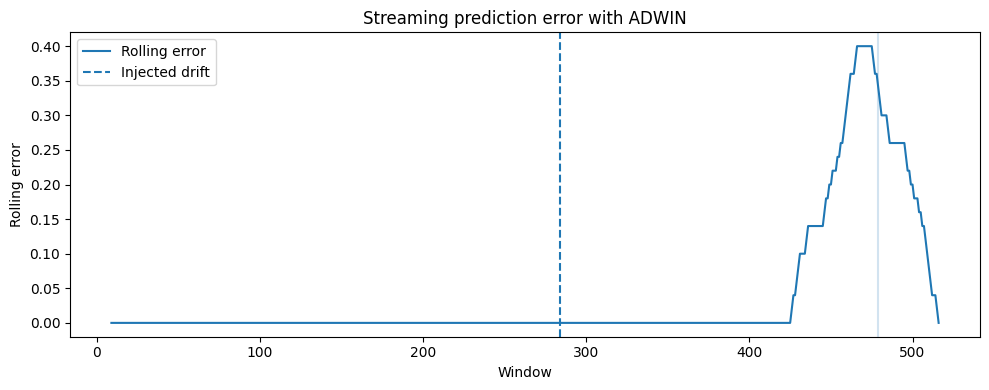

In [14]:

#@title 14. ADWIN streaming concept-drift experiment
from river.drift import ADWIN

stream = df.iloc[test].sort_values(["record", "start_sec"]).copy()
Xs = stream[fcols].copy()
ys = stream["label"].astype(int).to_numpy()

drift_start = int(0.55 * len(Xs))
rng = np.random.default_rng(SEED + 99)
std = df.iloc[train][fcols].std().fillna(0).to_numpy()

for i in range(drift_start, len(Xs)):
    frac = (i - drift_start) / max(1, len(Xs) - drift_start)
    severity = 0.05 + 0.30 * frac
    Xs.iloc[i] = Xs.iloc[i].astype(float) + rng.normal(size=len(fcols)) * std * severity

ps = predict_frame(Xs)
errors = (ps.argmax(axis=1) != ys).astype(int)

detector = ADWIN(delta=0.002)
alarms = []
for i, err in enumerate(errors):
    detector.update(float(err))
    if detector.drift_detected:
        alarms.append(i)

post = [a for a in alarms if a >= drift_start]
first_alarm = post[0] if post else np.nan

drift_df = pd.DataFrame([{
    "StreamWindows": len(Xs),
    "InjectedDriftStart": drift_start,
    "TotalADWINAlarms": len(alarms),
    "FalseAlarmsBeforeDrift": sum(a < drift_start for a in alarms),
    "FirstPostDriftAlarm": first_alarm,
    "DetectionDelayWindows": first_alarm-drift_start if np.isfinite(first_alarm) else np.nan
}])
display(drift_df)
drift_df.to_csv(OUT / "drift_detection_ADWIN.csv", index=False)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(pd.Series(errors).rolling(50, min_periods=10).mean().to_numpy(), label="Rolling error")
ax.axvline(drift_start, linestyle="--", label="Injected drift")
for a in alarms:
    ax.axvline(a, alpha=0.2)
ax.set_title("Streaming prediction error with ADWIN")
ax.set_xlabel("Window")
ax.set_ylabel("Rolling error")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "drift_monitoring.png", dpi=220, bbox_inches="tight")
plt.show()


,Feature,ImportanceMean,ImportanceStd
31,ppg_rate,0.116946,0.016627
14,ecg_rate,0.028248,0.012632
21,ppg_min,0.016094,0.005479
10,ecg_spec_centroid,0.010616,0.000000
3,ecg_iqr,0.005308,0.005308
6,ecg_rms,0.004578,0.003237
7,ecg_skew,0.004578,0.003237
2,ecg_median,0.002872,0.004150
33,ppg_rmssd,0.002289,0.003237
1,ecg_std,0.002289,0.003237


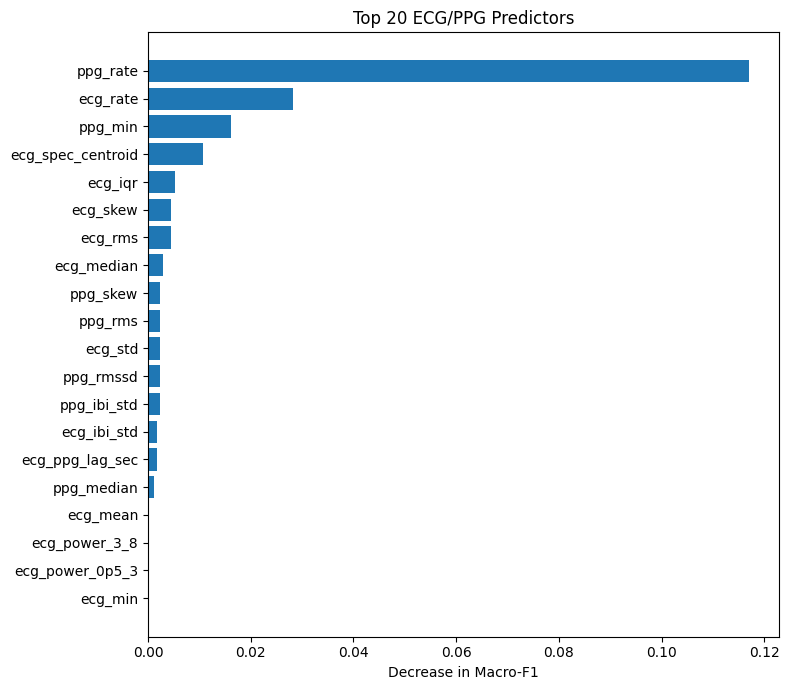

In [15]:

#@title 15. Explainability: permutation feature importance
best_name = list(fitted.keys())[int(np.argmax(weights))]
best_template = make_models()[best_name]

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("model", best_template)
])

sw = compute_sample_weight(class_weight="balanced", y=y[train])
try:
    pipe.fit(df.iloc[train][fcols], y[train], model__sample_weight=sw)
except TypeError:
    pipe.fit(df.iloc[train][fcols], y[train])

pi = permutation_importance(
    pipe,
    df.iloc[test][fcols],
    yt,
    scoring="f1_macro",
    n_repeats=6,
    random_state=SEED,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": fcols,
    "ImportanceMean": pi.importances_mean,
    "ImportanceStd": pi.importances_std
}).sort_values("ImportanceMean", ascending=False)

display(importance_df.head(20))
importance_df.to_csv(OUT / "permutation_feature_importance.csv", index=False)

top = importance_df.head(20).sort_values("ImportanceMean")
fig, ax = plt.subplots(figsize=(8,7))
ax.barh(top["Feature"], top["ImportanceMean"])
ax.set_title("Top 20 ECG/PPG Predictors")
ax.set_xlabel("Decrease in Macro-F1")
fig.tight_layout()
fig.savefig(OUT / "feature_importance_top20.png", dpi=220, bbox_inches="tight")
plt.show()


In [16]:

#@title 16. Bootstrap 95% CI and paired significance
def bootstrap_f1_ci(y_true, p, B=BOOTSTRAPS, seed=SEED):
    rng = np.random.default_rng(seed)
    pred = p.argmax(axis=1)
    vals = []
    for _ in range(B):
        ix = rng.integers(0, len(y_true), len(y_true))
        vals.append(f1_score(y_true[ix], pred[ix], average="macro", zero_division=0))
    vals = np.asarray(vals)
    return float(vals.mean()), float(np.quantile(vals, .025)), float(np.quantile(vals, .975))

ci_rows = []
comparison_probs = {
    "ECG_only": prob_store["ECG_only"][1],
    "PPG_only": prob_store["PPG_only"][1],
    "Fusion_calibrated": ptest
}

for name, p in comparison_probs.items():
    m, lo, hi = bootstrap_f1_ci(yt, p)
    ci_rows.append({
        "Model": name,
        "BootstrapMacroF1Mean": m,
        "CI95_Low": lo,
        "CI95_High": hi
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df.round(4))
ci_df.to_csv(OUT / "bootstrap_confidence_intervals.csv", index=False)

single_names = ["ECG_only", "PPG_only"]
best_single = max(
    single_names,
    key=lambda n: f1_score(yt, comparison_probs[n].argmax(1), average="macro", zero_division=0)
)
basep = comparison_probs[best_single]

rng = np.random.default_rng(SEED)
diffs = []
for _ in range(BOOTSTRAPS):
    ix = rng.integers(0, len(yt), len(yt))
    f_prop = f1_score(yt[ix], ptest.argmax(1)[ix], average="macro", zero_division=0)
    f_base = f1_score(yt[ix], basep.argmax(1)[ix], average="macro", zero_division=0)
    diffs.append(f_prop - f_base)

diffs = np.asarray(diffs)
pvalue = min(1.0, 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0)))

sig_df = pd.DataFrame([{
    "Comparison": f"Fusion calibrated vs {best_single}",
    "MeanMacroF1Difference": float(diffs.mean()),
    "CI95_Low": float(np.quantile(diffs, .025)),
    "CI95_High": float(np.quantile(diffs, .975)),
    "PairedBootstrapPValue": float(pvalue)
}])
display(sig_df.round(5))
sig_df.to_csv(OUT / "paired_bootstrap_significance.csv", index=False)


,Model,BootstrapMacroF1Mean,CI95_Low,CI95_High
0,ECG_only,0.7099,0.6422,0.7751
1,PPG_only,0.9031,0.8437,0.9527
2,Fusion_calibrated,0.9007,0.8408,0.9509


,Comparison,MeanMacroF1Difference,CI95_Low,CI95_High,PairedBootstrapPValue
0,Fusion calibrated vs PPG_only,-0.00245,-0.02614,0.01914,0.96667


,precision,recall,f1-score,support
Normal-rate,0.9979,0.9776,0.9876,490.0000
Tachycardia alert,0.7027,0.9630,0.8125,27.0000
accuracy,0.9768,0.9768,0.9768,0.9768
macro avg,0.8503,0.9703,0.9001,517.0000
weighted avg,0.9825,0.9768,0.9785,517.0000


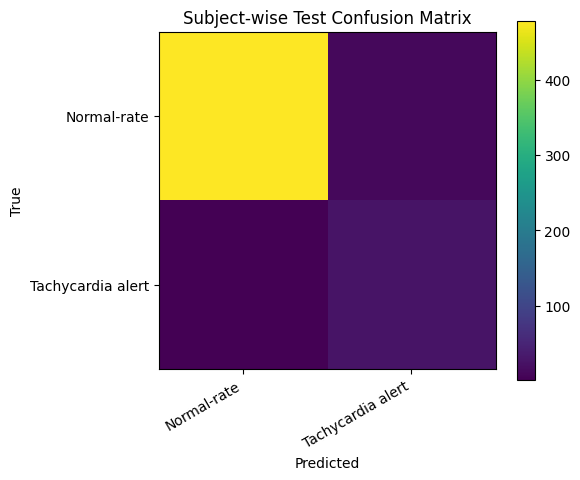

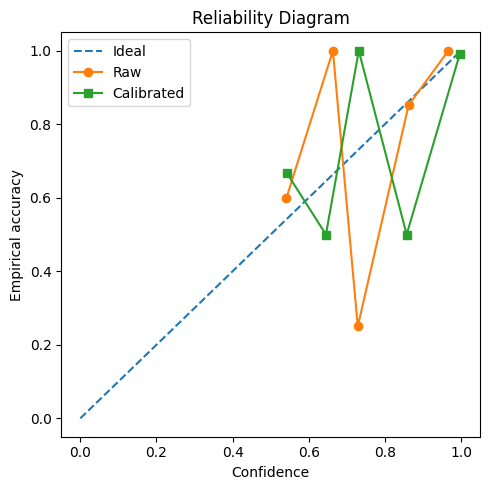

In [17]:

#@title 17. Confusion matrix, classification report, and reliability diagram
pred = ptest.argmax(axis=1)

report_df = pd.DataFrame(
    classification_report(
        yt, pred,
        labels=CLASSES,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).T
display(report_df.round(4))
report_df.to_csv(OUT / "classification_report.csv")

cm = confusion_matrix(yt, pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm)
fig.colorbar(im, ax=ax)
ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Subject-wise Test Confusion Matrix")
fig.tight_layout()
fig.savefig(OUT / "confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()

def reliability_points(y_true, p):
    conf = p.max(axis=1)
    pr = p.argmax(axis=1)
    correct = pr == y_true
    xs, ys_ = [], []
    for lo, hi in zip(np.linspace(0,1,11)[:-1], np.linspace(0,1,11)[1:]):
        m = (conf > lo) & (conf <= hi)
        if np.any(m):
            xs.append(float(conf[m].mean()))
            ys_.append(float(correct[m].mean()))
    return xs, ys_

fig, ax = plt.subplots(figsize=(5,5))
x0, y0 = reliability_points(yt, ptest_raw)
x1, y1 = reliability_points(yt, ptest)
ax.plot([0,1], [0,1], "--", label="Ideal")
ax.plot(x0, y0, marker="o", label="Raw")
ax.plot(x1, y1, marker="s", label="Calibrated")
ax.set_xlabel("Confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_title("Reliability Diagram")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "reliability_diagram.png", dpi=220, bbox_inches="tight")
plt.show()


In [18]:

#@title 18. Edge resource profiling
imputer, fitted, weights, fcols = objects["ECG_PPG_Fusion"]
Xedge = df.iloc[test][fcols].head(min(500, len(test)))
Zedge = imputer.transform(Xedge)

profile_rows = []
for name, model in fitted.items():
    warm = min(20, len(Zedge))
    _ = model.predict_proba(Zedge[:warm])

    repeats = 20
    t0 = time.perf_counter()
    for _ in range(repeats):
        _ = model.predict_proba(Zedge)
    elapsed = (time.perf_counter() - t0) / repeats

    model_path = OUT / f"{name}_edge_model.joblib"
    joblib.dump(model, model_path, compress=3)

    profile_rows.append({
        "Model": name,
        "N_Profiled": len(Zedge),
        "BatchLatency_ms": elapsed * 1000,
        "Latency_ms_per_window": elapsed * 1000 / max(1, len(Zedge)),
        "Throughput_windows_per_sec": len(Zedge) / elapsed,
        "SerializedSize_MB": model_path.stat().st_size / (1024**2)
    })

profile_df = pd.DataFrame(profile_rows)
display(profile_df.round(4))
profile_df.to_csv(OUT / "edge_resource_profile.csv", index=False)


,Model,N_Profiled,BatchLatency_ms,Latency_ms_per_window,Throughput_windows_per_sec,SerializedSize_MB
0,ExtraTrees,500,139.2362,0.2785,3591.0212,1.3370
1,XGBoost,500,2.7475,0.0055,181985.4463,0.0652
2,LightGBM,500,5.6750,0.0113,88106.0343,0.1541


In [19]:

#@title 19. Master ablation table and uncertainty predictions
master_df = pd.DataFrame([
    metric_row("ECG_only_ensemble", yt, prob_store["ECG_only"][1]),
    metric_row("PPG_only_ensemble", yt, prob_store["PPG_only"][1]),
    metric_row("ECG_PPG_fusion_raw", yt, ptest_raw),
    metric_row("Proposed_calibrated_fusion", yt, ptest),
])
display(master_df.round(4))
master_df.to_csv(OUT / "master_ablation_results.csv", index=False)

sets90 = conf_sets[0.10]
pred_df = df.iloc[test][["record","start_sec","hr_reference","original_label","label"]].copy().reset_index(drop=True)
pred_df["true_label_name"] = CLASS_NAMES[yt]
pred_df["predicted_label"] = pred
pred_df["predicted_label_name"] = CLASS_NAMES[pred]
pred_df["confidence"] = ptest.max(axis=1)
pred_df["conformal_set_size_90"] = sets90.sum(axis=1)
pred_df["conformal_set_90"] = [
    " | ".join(CLASS_NAMES[sets90[i]]) for i in range(len(sets90))
]
pred_df.to_csv(OUT / "test_predictions_with_uncertainty.csv", index=False)
display(pred_df.head())


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,Brier,ECE,LogLoss,AUROC,AUPRC
0,ECG_only_ensemble,0.9014,0.8780,0.6598,0.8780,0.7099,0.9210,0.1046,0.0777,0.1710,0.9518,0.6864
1,PPG_only_ensemble,0.9768,0.9878,0.8462,0.9878,0.9029,0.9788,0.0499,0.0125,0.0980,0.9895,0.7984
2,ECG_PPG_fusion_raw,0.9768,0.9703,0.8503,0.9703,0.9001,0.9785,0.0369,0.0439,0.0815,0.9943,0.8988
3,Proposed_calibrated_fusion,0.9768,0.9703,0.8503,0.9703,0.9001,0.9785,0.0389,0.0161,0.0659,0.9943,0.8988


,record,start_sec,hr_reference,original_label,label,true_label_name,predicted_label,predicted_label_name,confidence,conformal_set_size_90,conformal_set_90
0,bidmc04,0.0,94.000062,1,0,Normal-rate,0,Normal-rate,0.997110,1,Normal-rate
1,bidmc04,10.0,94.000062,1,0,Normal-rate,0,Normal-rate,0.996720,1,Normal-rate
2,bidmc04,20.0,93.000046,1,0,Normal-rate,0,Normal-rate,0.996720,1,Normal-rate
3,bidmc04,30.0,94.000062,1,0,Normal-rate,0,Normal-rate,0.998139,1,Normal-rate
4,bidmc04,40.0,94.000062,1,0,Normal-rate,0,Normal-rate,0.998774,1,Normal-rate


In [20]:

#@title 20. FULL-RUN verification, manifest, ZIP, and download
manifest = {
    "paper_title": "An Uncertainty-Aware Explainable and Drift-Adaptive Edge-IoMT Framework for Real-Time Cardiovascular Event Detection from Wearable ECG and PPG Signals",
    "dataset": "PhysioNet BIDMC PPG and Respiration Dataset v1.0.0",
    "endpoint": "monitor-derived HR alert states: <50, 50-100, >100 bpm; only classes present in data are modeled",
    "class_names": CLASS_NAMES.tolist(),
    "n_classes": int(N_CLASSES),
    "seed": SEED,
    "fs": FS,
    "window_sec": WINDOW_SEC,
    "step_sec": STEP_SEC,
    "bootstrap_replicates": BOOTSTRAPS,
    "n_windows": int(len(df)),
    "n_records": int(df.record.nunique()),
    "temperature": float(T),
    "numpy_version": np.__version__,
    "scipy_version": scipy.__version__,
    "pandas_version": pd.__version__,
}
with open(OUT / "reproducibility_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

required = [
    "dataset_audit.csv",
    "all_window_features_raw_labels.csv",
    "subjectwise_split_summary.csv",
    "modality_model_comparison.csv",
    "calibration_comparison.csv",
    "conformal_prediction_sets.csv",
    "edge_cloud_selective_prediction.csv",
    "noise_missing_sensor_robustness.csv",
    "drift_detection_ADWIN.csv",
    "permutation_feature_importance.csv",
    "bootstrap_confidence_intervals.csv",
    "paired_bootstrap_significance.csv",
    "classification_report.csv",
    "edge_resource_profile.csv",
    "master_ablation_results.csv",
    "test_predictions_with_uncertainty.csv",
    "reproducibility_manifest.json",
]
missing = [name for name in required if not (OUT / name).exists()]
assert not missing, f"Missing mandatory outputs: {missing}"

zip_path = Path("/content/Edge_IoMT_ECG_PPG_FULL_RESULTS_FIXED.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.rglob("*"):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUT))

print("FULL RUN COMPLETE")
print("Results ZIP:", zip_path)
print("ZIP size (MB):", round(zip_path.stat().st_size / 1e6, 2))
print("\nGenerated outputs:")
for p in sorted(OUT.iterdir()):
    print(" -", p.name)

from google.colab import files
files.download(str(zip_path))


FULL RUN COMPLETE
Results ZIP: /content/Edge_IoMT_ECG_PPG_FULL_RESULTS_FIXED.zip
ZIP size (MB): 2.67

Generated outputs:
 - ExtraTrees_edge_model.joblib
 - LightGBM_edge_model.joblib
 - XGBoost_edge_model.joblib
 - all_window_features_raw_labels.csv
 - bootstrap_confidence_intervals.csv
 - calibration_comparison.csv
 - classification_report.csv
 - conformal_prediction_sets.csv
 - confusion_matrix.png
 - dataset_audit.csv
 - download_validation.csv
 - drift_detection_ADWIN.csv
 - drift_monitoring.png
 - edge_cloud_selective_prediction.csv
 - edge_resource_profile.csv
 - feature_importance_top20.png
 - master_ablation_results.csv
 - modality_model_comparison.csv
 - noise_missing_sensor_robustness.csv
 - paired_bootstrap_significance.csv
 - permutation_feature_importance.csv
 - reliability_diagram.png
 - reproducibility_manifest.json
 - subjectwise_split_summary.csv
 - test_predictions_with_uncertainty.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Publication reporting rules
1. Use only subject-wise test results.
2. Describe the endpoint as **monitor-derived cardiovascular alert states**, not adjudicated arrhythmias.
3. ADWIN is a controlled simulated sensor-distribution-shift experiment.
4. Colab latency is a Colab CPU benchmark, not Raspberry Pi/ESP32 latency.
5. For stronger clinical claims, add an independent arrhythmia-labelled dataset as external validation.
